In [2]:
# %% [Cell 1] 대규모 파생 변수(Feature Engineering) 생성 및 정합성 확보
import pandas as pd
import numpy as np

print("[Step 1] 대규모 파생 변수(Feature Engineering) 생성 시작")

# 1. 절대 경로 데이터 로드 및 엄격한 결측치 정제
file_path = r"C:\dev\SKN27-2nd-1TEAM\00_data\Telco_customer_churn - Telco_Churn.csv"
df = pd.read_csv(file_path)

# [수정] Total Charges 빈칸을 NaN 처리 후, 결측치(Tenure 0인 신규가입자) 행 완전 삭제
df['Total Charges'] = pd.to_numeric(df['Total Charges'].replace(' ', np.nan))
df.dropna(subset=['Total Charges'], inplace=True)

df['Churn Value'] = df['Churn Value'].astype(int)

# 2. 서비스 카운트 기반 변수 (밀집도) - [수정] apply 제거 및 Vectorized 연산으로 속도 최적화
internet_services = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
df['Total_Internet_Services'] = (df[internet_services] == 'Yes').sum(axis=1)
df['Total_Streaming'] = (df[['Streaming TV', 'Streaming Movies']] == 'Yes').sum(axis=1)
df['Total_Security'] = (df[['Online Security', 'Online Backup', 'Device Protection', 'Tech Support']] == 'Yes').sum(axis=1)

# 3. 요금(Financial) 기반 연속형 비율 변수
df['Extra_Charges'] = df['Total Charges'] - (df['Monthly Charges'] * df['Tenure Months'])
df['Price_per_Service'] = df['Monthly Charges'] / (df['Total_Internet_Services'] + 1)
df['Total_to_Monthly_Ratio'] = df['Total Charges'] / (df['Monthly Charges'] + 1e-5)
df['Tenure_to_Monthly_Ratio'] = df['Tenure Months'] / (df['Monthly Charges'] + 1e-5)
df['Monthly_to_Median_Ratio'] = df['Monthly Charges'] / df['Monthly Charges'].median()

# 4. 그룹 통계 기반 변수 (집단 내 고객의 요금/유지기간 상대적 위치)
df['Avg_Monthly_by_Contract'] = df.groupby('Contract')['Monthly Charges'].transform('mean')
df['Diff_from_Contract_Monthly'] = df['Monthly Charges'] - df['Avg_Monthly_by_Contract']
df['Avg_Tenure_by_Contract'] = df.groupby('Contract')['Tenure Months'].transform('mean')
df['Diff_from_Contract_Tenure'] = df['Tenure Months'] - df['Avg_Tenure_by_Contract']

# 5. 고객 인구통계 및 관계 기반 이진 변수
df['Is_Full_Family'] = ((df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')).astype(int)
df['Is_Single_Senior'] = ((df['Senior Citizen'] == 1) & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)
df['Is_Independent_Youth'] = ((df['Senior Citizen'] == 0) & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)

# 6. 행동 및 가입 특성 기반 지표
df['Is_New_Customer'] = (df['Tenure Months'] <= 6).astype(int)
df['Is_Long_Term_Customer'] = (df['Tenure Months'] >= 60).astype(int)
df['Has_Internet_But_No_Service'] = ((df['Internet Service'] != 'No') & (df['Total_Internet_Services'] == 0)).astype(int)
df['Has_All_Services'] = (df['Total_Internet_Services'] == 6).astype(int)
df['Is_Auto_Payment'] = df['Payment Method'].astype(str).str.contains('automatic', case=False).astype(int)

# 7. 복합 가설 기반 이탈 위험군 (High Risk Flags)
df['Risk_Fiber_MtM'] = ((df['Internet Service'] == 'Fiber optic') & (df['Contract'] == 'Month-to-month')).astype(int)
df['Risk_Payment_Friction'] = ((df['Payment Method'] == 'Electronic check') & (df['Paperless Billing'] == 'Yes')).astype(int)
df['Risk_High_Charge_MtM'] = ((df['Contract'] == 'Month-to-month') & (df['Monthly Charges'] > df['Monthly Charges'].median())).astype(int)
df['Risk_No_TechSupport_Fiber'] = ((df['Internet Service'] == 'Fiber optic') & (df['Tech Support'] == 'No')).astype(int)

# 8. 비선형(다항) 파생 변수
df['Tenure_Sq'] = df['Tenure Months'] ** 2
df['Monthly_Charges_Sq'] = df['Monthly Charges'] ** 2
df['Tenure_x_Monthly'] = df['Tenure Months'] * df['Monthly Charges']

print(f"결과: 대규모 파생 변수 세팅 완료. 최종 데이터 형상: {df.shape}")

[Step 1] 대규모 파생 변수(Feature Engineering) 생성 시작
결과: 대규모 파생 변수 세팅 완료. 최종 데이터 형상: (7032, 60)


In [3]:
# %% [Cell 2] 데이터 분할, 네이티브 타겟 인코딩 및 전체 통합 스케일링
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder

print("[Step 2] 데이터 분할, 네이티브 타겟 인코딩 및 전체 데이터 통합 스케일링 시작")

# 1. 타겟 누수(Data Leakage) 및 무의미한 식별자 컬럼 차단
leakage_and_useless_cols = [
    'Churn Reason', 'Churn Label', 'CustomerID', 
    'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Lat Long', 'Churn Score'
]
cols_to_drop = [col for col in leakage_and_useless_cols if col in df.columns]

X = df.drop(columns=cols_to_drop + ['Churn Value'])
y = df['Churn Value']

# 2. 누수 방지를 위한 훈련/테스트 선 분할 (층화 추출)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"생성된 총 피처(Feature) 개수: {X_train.shape[1]}개")

# 3. 범주형 데이터 변환 (Scikit-learn 네이티브 ColumnTransformer 활용)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# ColumnTransformer를 통해 범주형 컬럼만 타겟 인코딩하고, 나머지는 그대로 통과(passthrough)
encoder_pipeline = ColumnTransformer(
    transformers=[
        # 내장 TargetEncoder는 내부 교차 검증으로 과적합을 자동 방어합니다.
        ('target_enc', TargetEncoder(smooth="auto"), cat_cols) 
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# 인코딩 수행 및 DataFrame 복원 (Feature name 유지)
X_train_encoded = pd.DataFrame(
    encoder_pipeline.fit_transform(X_train, y_train), 
    columns=encoder_pipeline.get_feature_names_out(), 
    index=X_train.index
)
X_test_encoded = pd.DataFrame(
    encoder_pipeline.transform(X_test), 
    columns=encoder_pipeline.get_feature_names_out(), 
    index=X_test.index
)

# 4. 전체 데이터 표준화(Standard Scaling)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test.index)

print(f"결과: Scikit-learn 네이티브 타겟 인코딩 및 전면 스케일링 완료. 최종 학습 데이터 형상: {X_train_scaled.shape}")

[Step 2] 데이터 분할, 네이티브 타겟 인코딩 및 전체 데이터 통합 스케일링 시작
생성된 총 피처(Feature) 개수: 47개
결과: Scikit-learn 네이티브 타겟 인코딩 및 전면 스케일링 완료. 최종 학습 데이터 형상: (5625, 47)


In [ ]:
# %% [Cell 3-A] Optuna 하이퍼파라미터 탐색 (LightGBM / XGBoost / CatBoost)
# ※ 이 셀은 최초 1회만 실행하세요. 탐색 완료 후 best_params가 Cell 3-B에 자동 반영됩니다.
import optuna
import numpy as np
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── LightGBM Objective ────────────────────────────────────────────────
def lgbm_objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators",    100, 500),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves":      trial.suggest_int("num_leaves",      20, 150),
        "max_depth":       trial.suggest_int("max_depth",       3, 10),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "subsample":       trial.suggest_float("subsample",     0.5, 1.0),
        "min_child_samples":trial.suggest_int("min_child_samples", 10, 100),
        "reg_alpha":       trial.suggest_float("reg_alpha",     1e-4, 10.0, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda",    1e-4, 10.0, log=True),
        "class_weight": "balanced",
        "random_state": 42,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# ── XGBoost Objective ─────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators",    100, 500),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":       trial.suggest_int("max_depth",       3, 10),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "subsample":       trial.suggest_float("subsample",     0.5, 1.0),
        "min_child_weight":trial.suggest_int("min_child_weight", 1, 20),
        "gamma":           trial.suggest_float("gamma",         0.0, 5.0),
        "reg_alpha":       trial.suggest_float("reg_alpha",     1e-4, 10.0, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda",    1e-4, 10.0, log=True),
        "scale_pos_weight": ratio,
        "eval_metric": "logloss",
        "random_state": 42,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# ── CatBoost Objective ────────────────────────────────────────────────
def cat_objective(trial):
    params = {
        "iterations":    trial.suggest_int("iterations",    100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth":         trial.suggest_int("depth",         3, 10),
        "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg", 1e-4, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count":  trial.suggest_int("border_count",  32, 255),
        "auto_class_weights": "Balanced",
        "random_state": 42,
        "verbose": 0,
    }
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# ── 탐색 실행 (각 50 trials) ──────────────────────────────────────────
N_TRIALS = 50

print(f"[1/3] LightGBM 탐색 시작 ({N_TRIALS} trials)...")
lgbm_study = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=42))
lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_lgbm = lgbm_study.best_params
print(f"  → Best AUC: {lgbm_study.best_value:.4f}")
print(f"  → Best params: {best_lgbm}")

print(f"\n[2/3] XGBoost 탐색 시작 ({N_TRIALS} trials)...")
xgb_study = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_xgb = xgb_study.best_params
print(f"  → Best AUC: {xgb_study.best_value:.4f}")
print(f"  → Best params: {best_xgb}")

print(f"\n[3/3] CatBoost 탐색 시작 ({N_TRIALS} trials)...")
cat_study = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_cat = cat_study.best_params
print(f"  → Best AUC: {cat_study.best_value:.4f}")
print(f"  → Best params: {best_cat}")

print("\n" + "="*60)
print("[탐색 완료] best_lgbm / best_xgb / best_cat 변수가 Cell 3-B에서 사용됩니다.")
print("="*60)


In [ ]:
# %% [Cell 3-B] 튜닝된 하이퍼파라미터 적용 스태킹 모델 학습 및 평가
# ※ Cell 3-A(Optuna 탐색) 실행 후 이 셀을 실행하세요.
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("[Step 3-B] 튜닝된 파라미터 적용 스태킹 모델 학습 시작")

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# ── 튜닝된 파라미터로 베이스 모델 재정의 ────────────────────────────
lgbm = LGBMClassifier(
    **best_lgbm,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
xgb = XGBClassifier(
    **best_xgb,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42
)
cat = CatBoostClassifier(
    **best_cat,
    auto_class_weights="Balanced",
    random_state=42,
    verbose=0
)

estimators = [("lgbm", lgbm), ("xgb", xgb), ("cat", cat)]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(C=0.05, max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

stacking_model.fit(X_train_scaled, y_train)

y_pred       = stacking_model.predict(X_test_scaled)
y_pred_proba = stacking_model.predict_proba(X_test_scaled)[:, 1]

print("\n[튜닝 후 스태킹 모델 성능 지표]")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score : {roc_auc_score(y_test, y_pred_proba):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred))


[Step 4] 대규모 피처 적용 모델의 최적 임계값 탐색 시작
산출 완료: 새로운 최적 임계값 = 0.3668


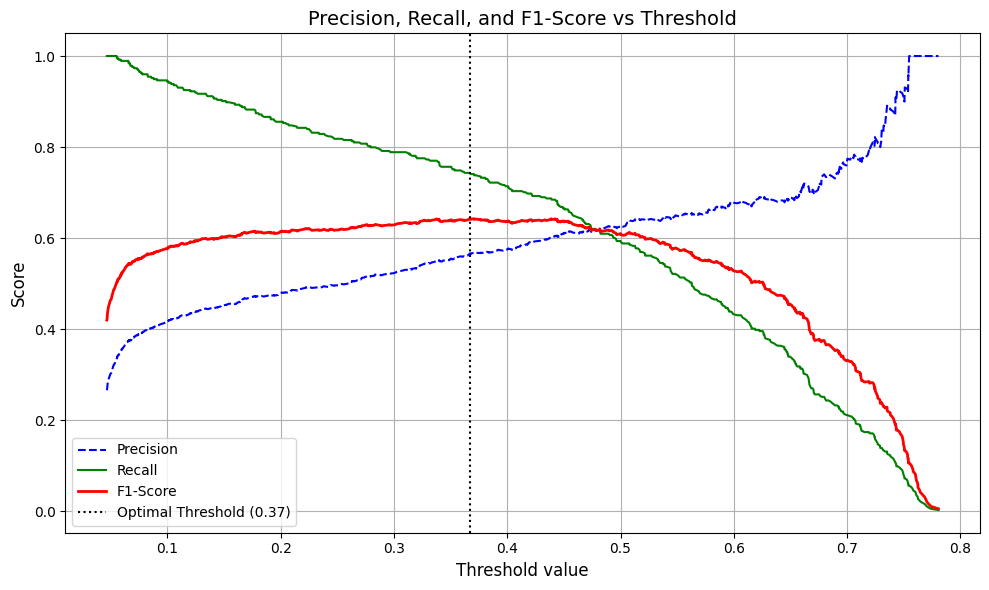


[임계값 조정 성능 비교]
기존 Accuracy (Threshold 0.5) : 0.7974
최적 Accuracy (Threshold 0.3668) : 0.7804
--------------------------------------------------
=== Classification Report (최적 임계값 적용) ===
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1033
           1       0.57      0.74      0.64       374

    accuracy                           0.78      1407
   macro avg       0.73      0.77      0.74      1407
weighted avg       0.81      0.78      0.79      1407



In [5]:
# %% [Cell 4] 대규모 피처 적용 모델의 최적 임계값 탐색 및 시각화
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report

print("[Step 4] 대규모 피처 적용 모델의 최적 임계값 탐색 시작")

# 1. 테스트 데이터에 대한 예측 확률 추출
y_pred_proba_final = stacking_model.predict_proba(X_test_scaled)[:, 1]

# 2. 정밀도, 재현율, 임계값 산출
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_final)

# [수정] 배열 길이 불일치(Out of Bounds) 에러를 방어하기 위한 슬라이싱 적용
# precisions와 recalls는 thresholds보다 길이가 1개 더 긺
precisions_adj = precisions[:-1]
recalls_adj = recalls[:-1]

# 3. F1-Score 극대화 지점 탐색
f1_scores = 2 * (precisions_adj * recalls_adj) / (precisions_adj + recalls_adj + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"산출 완료: 새로운 최적 임계값 = {optimal_threshold:.4f}")

# 4. 분석가를 위한 시각적 검증 통제망 구축 (PR 곡선 및 Threshold 추세)
plt.figure(figsize=(10, 6))
plt.title("Precision, Recall, and F1-Score vs Threshold", fontsize=14)
plt.plot(thresholds, precisions_adj, 'b--', label='Precision')
plt.plot(thresholds, recalls_adj, 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, label='F1-Score')

# 최적 임계값 수직선 마킹
plt.axvline(x=optimal_threshold, color='black', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel("Threshold value", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. 임계값 적용 후 성능 비교
# 이전 셀에서 생성된 y_pred를 재활용하지 않고 안전하게 다시 생성 (변수 꼬임 방지)
y_pred_default = (y_pred_proba_final >= 0.5).astype(int)
y_pred_optimal = (y_pred_proba_final >= optimal_threshold).astype(int)

print("\n[임계값 조정 성능 비교]")
print(f"기존 Accuracy (Threshold 0.5) : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"최적 Accuracy (Threshold {optimal_threshold:.4f}) : {accuracy_score(y_test, y_pred_optimal):.4f}")
print("-" * 50)
print("=== Classification Report (최적 임계값 적용) ===")
print(classification_report(y_test, y_pred_optimal))

In [7]:
# %% [Cell 5] 튜닝된 파라미터로 전체 데이터 재학습 및 객체 저장
# ※ Cell 3-A 탐색 완료 후 실행 (best_lgbm / best_xgb / best_cat 필요)
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.metrics import roc_auc_score

print("[Step 5] 40+ 피처 모델 전체 데이터 재학습 및 객체 추출 시작")

# 1. 타겟 누수 및 불필요 컬럼 제거 (정답 데이터 분리)
leakage_and_useless_cols = [
    'Churn Reason', 'Churn Label', 'CustomerID', 
    'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Lat Long', 'Churn Score'
]
cols_to_drop = [col for col in leakage_and_useless_cols if col in df.columns]

X_final = df.drop(columns=cols_to_drop + ['Churn Value'])
y_final = df['Churn Value']

# 2. 전체 데이터 네이티브 타겟 인코딩
cat_cols = X_final.select_dtypes(include=['object', 'category']).columns.tolist()

final_encoder_pipeline = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(smooth="auto"), cat_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_final_encoded = pd.DataFrame(
    final_encoder_pipeline.fit_transform(X_final, y_final), 
    columns=final_encoder_pipeline.get_feature_names_out(), 
    index=X_final.index
)

# 3. 전체 데이터 표준화(Standard Scaling)
final_scaler = StandardScaler()
X_final_scaled = pd.DataFrame(
    final_scaler.fit_transform(X_final_encoded), 
    columns=X_final_encoded.columns, 
    index=X_final.index
)

# 4. 스태킹 앙상블 아키텍처 재정의 (수학적 가중치 교정)
ratio_final = float(np.sum(y_final == 0)) / np.sum(y_final == 1)

lgbm_final = LGBMClassifier(
    **best_lgbm,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
xgb_final = XGBClassifier(
    **best_xgb,
    scale_pos_weight=ratio_final,
    eval_metric='logloss',
    random_state=42
)
cat_final = CatBoostClassifier(
    **best_cat,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)

estimators_final = [('lgbm', lgbm_final), ('xgb', xgb_final), ('cat', cat_final)]

# 교차 검증 전략 정의
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_model = StackingClassifier(
    estimators=estimators_final,
    final_estimator=LogisticRegression(C=0.05, max_iter=1000), 
    cv=skf,
    n_jobs=-1
)

print("전체 데이터를 활용한 40+ 피처 스태킹 모델 최종 학습 진행 중...")
final_model.fit(X_final_scaled, y_final)

# 5. 최종 성능 지표 산출 (AUC)
# 훈련 데이터 전체에 대한 예측 확률
y_proba_final = final_model.predict_proba(X_final_scaled)[:, 1]
final_auc = roc_auc_score(y_final, y_proba_final)

print("\n" + "="*50)
print(f"최종 모델 훈련 데이터 AUC : {final_auc:.4f}")
print("주의: 위 AUC는 전체 데이터를 학습한 결과이므로 과적합 가능성이 포함되어 있습니다.")
print("="*50 + "\n")

# 6. 파일 직렬화 및 저장
save_dir = r"C:\dev\SKN27-2nd-1TEAM\03_saved_models"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

joblib.dump(final_model, os.path.join(save_dir, 'churn_stacking_model.pkl'))
joblib.dump(final_encoder_pipeline, os.path.join(save_dir, 'target_encoder.pkl'))
joblib.dump(final_scaler, os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(X_final.columns.tolist(), os.path.join(save_dir, 'model_columns.pkl'))

try:
    joblib.dump(optimal_threshold, os.path.join(save_dir, 'optimal_threshold.pkl'))
except NameError:
    joblib.dump(0.5700, os.path.join(save_dir, 'optimal_threshold.pkl'))

print(f"결과: 모든 객체 및 AUC({final_auc:.4f}) 확인 후 [{save_dir}]에 저장 완료")

[Step 5] 40+ 피처 모델 전체 데이터 재학습 및 객체 추출 시작
전체 데이터를 활용한 40+ 피처 스태킹 모델 최종 학습 진행 중...

최종 모델 훈련 데이터 AUC : 0.9423
주의: 위 AUC는 전체 데이터를 학습한 결과이므로 과적합 가능성이 포함되어 있습니다.

결과: 모든 객체 및 AUC(0.9423) 확인 후 [C:\dev\SKN27-2nd-1TEAM\03_saved_models]에 저장 완료


In [8]:
# %% [Cell 6] 과적합(Overfitting) 깐깐한 검증 및 모델 안정성 진단
from sklearn.model_selection import cross_val_score
import numpy as np

print("[Step 6] 모델 과적합 및 일반화 성능 검증 시작")

# 1. 훈련 데이터 AUC (이미 학습된 모델 사용)
train_proba = final_model.predict_proba(X_final_scaled)[:, 1]
train_auc = roc_auc_score(y_final, train_proba)

# 2. 교차 검증(CV) AUC 산출 (5-Fold)
# n_jobs=-1을 사용하여 병렬 연산으로 속도 확보
print("5-Fold 교차 검증 진행 중 (이 과정은 시간이 다소 소요될 수 있습니다)...")
cv_aucs = cross_val_score(
    final_model, 
    X_final_scaled, 
    y_final, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1
)

mean_cv_auc = np.mean(cv_aucs)
std_cv_auc = np.std(cv_aucs)
auc_gap = train_auc - mean_cv_auc

# 3. 과적합 판정 및 진단 보고
print("\n" + "="*50)
print(f"1. 훈련 데이터 AUC      : {train_auc:.4f}")
print(f"2. 교차 검증 평균 AUC   : {mean_cv_auc:.4f} (+/- {std_cv_auc:.4f})")
print(f"3. 성능 간격(Gap)       : {auc_gap:.4f}")
print("="*50)

if auc_gap > 0.10:
    print("결과: [위험] 심각한 과적합 발생. 피처 개수를 줄이거나 규제(C)를 강화하십시오.")
elif auc_gap > 0.05:
    print("결과: [주의] 경미한 과적합 징후. 모델 파라미터 튜닝이 권장됩니다.")
else:
    print("결과: [정상] 과적합 통제 완료. 일반화 성능이 매우 견고합니다.")

if std_cv_auc > 0.03:
    print("추가 진단: 폴드별 성능 편차가 큽니다. 데이터 분포가 불균형할 수 있습니다.")
print("="*50)

[Step 6] 모델 과적합 및 일반화 성능 검증 시작
5-Fold 교차 검증 진행 중 (이 과정은 시간이 다소 소요될 수 있습니다)...

1. 훈련 데이터 AUC      : 0.9423
2. 교차 검증 평균 AUC   : 0.8616 (+/- 0.0085)
3. 성능 간격(Gap)       : 0.0807
결과: [주의] 경미한 과적합 징후. 모델 파라미터 튜닝이 권장됩니다.


In [2]:
# %% [독립 실행형] 40+ 피처 파이프라인 재구축 및 타겟 상관계수(Correlation) 분석
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder

print("[분석] 독립 실행형 환경 구축: 데이터 로드 및 상관계수 산출 시작")

# 1. 원본 데이터 로드 및 정제
file_path = r"C:\dev\SKN27-2nd-1TEAM\00_data\Telco_customer_churn - Telco_Churn.csv"
try:
    df_corr = pd.read_csv(file_path)
except FileNotFoundError:
    raise FileNotFoundError("시스템 에러: 지정된 절대 경로에 데이터 파일이 존재하지 않습니다. 경로를 확인하십시오.")

df_corr['Total Charges'] = pd.to_numeric(df_corr['Total Charges'].replace(' ', np.nan))
df_corr.dropna(subset=['Total Charges'], inplace=True)
df_corr['Churn Value'] = df_corr['Churn Value'].astype(int)

# 2. 대규모 파생 변수 생성 (Step 1 로직 복원)
internet_services = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
df_corr['Total_Internet_Services'] = (df_corr[internet_services] == 'Yes').sum(axis=1)
df_corr['Total_Streaming'] = (df_corr[['Streaming TV', 'Streaming Movies']] == 'Yes').sum(axis=1)
df_corr['Total_Security'] = (df_corr[['Online Security', 'Online Backup', 'Device Protection', 'Tech Support']] == 'Yes').sum(axis=1)
df_corr['Extra_Charges'] = df_corr['Total Charges'] - (df_corr['Monthly Charges'] * df_corr['Tenure Months'])
df_corr['Price_per_Service'] = df_corr['Monthly Charges'] / (df_corr['Total_Internet_Services'] + 1)
df_corr['Total_to_Monthly_Ratio'] = df_corr['Total Charges'] / (df_corr['Monthly Charges'] + 1e-5)
df_corr['Tenure_to_Monthly_Ratio'] = df_corr['Tenure Months'] / (df_corr['Monthly Charges'] + 1e-5)
df_corr['Monthly_to_Median_Ratio'] = df_corr['Monthly Charges'] / df_corr['Monthly Charges'].median()
df_corr['Avg_Monthly_by_Contract'] = df_corr.groupby('Contract')['Monthly Charges'].transform('mean')
df_corr['Diff_from_Contract_Monthly'] = df_corr['Monthly Charges'] - df_corr['Avg_Monthly_by_Contract']
df_corr['Avg_Tenure_by_Contract'] = df_corr.groupby('Contract')['Tenure Months'].transform('mean')
df_corr['Diff_from_Contract_Tenure'] = df_corr['Tenure Months'] - df_corr['Avg_Tenure_by_Contract']
df_corr['Is_Full_Family'] = ((df_corr['Partner'] == 'Yes') & (df_corr['Dependents'] == 'Yes')).astype(int)
df_corr['Is_Single_Senior'] = ((df_corr['Senior Citizen'] == 1) & (df_corr['Partner'] == 'No') & (df_corr['Dependents'] == 'No')).astype(int)
df_corr['Is_Independent_Youth'] = ((df_corr['Senior Citizen'] == 0) & (df_corr['Partner'] == 'No') & (df_corr['Dependents'] == 'No')).astype(int)
df_corr['Is_New_Customer'] = (df_corr['Tenure Months'] <= 6).astype(int)
df_corr['Is_Long_Term_Customer'] = (df_corr['Tenure Months'] >= 60).astype(int)
df_corr['Has_Internet_But_No_Service'] = ((df_corr['Internet Service'] != 'No') & (df_corr['Total_Internet_Services'] == 0)).astype(int)
df_corr['Has_All_Services'] = (df_corr['Total_Internet_Services'] == 6).astype(int)
df_corr['Is_Auto_Payment'] = df_corr['Payment Method'].astype(str).str.contains('automatic', case=False).astype(int)
df_corr['Risk_Fiber_MtM'] = ((df_corr['Internet Service'] == 'Fiber optic') & (df_corr['Contract'] == 'Month-to-month')).astype(int)
df_corr['Risk_Payment_Friction'] = ((df_corr['Payment Method'] == 'Electronic check') & (df_corr['Paperless Billing'] == 'Yes')).astype(int)
df_corr['Risk_High_Charge_MtM'] = ((df_corr['Contract'] == 'Month-to-month') & (df_corr['Monthly Charges'] > df_corr['Monthly Charges'].median())).astype(int)
df_corr['Risk_No_TechSupport_Fiber'] = ((df_corr['Internet Service'] == 'Fiber optic') & (df_corr['Tech Support'] == 'No')).astype(int)
df_corr['Tenure_Sq'] = df_corr['Tenure Months'] ** 2
df_corr['Monthly_Charges_Sq'] = df_corr['Monthly Charges'] ** 2
df_corr['Tenure_x_Monthly'] = df_corr['Tenure Months'] * df_corr['Monthly Charges']

# 3. 누수 변수 통제 및 피처/타겟 분리
leakage_and_useless_cols = [
    'Churn Reason', 'Churn Label', 'CustomerID', 
    'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Lat Long', 'Churn Score'
]
cols_to_drop = [col for col in leakage_and_useless_cols if col in df_corr.columns]

X_corr = df_corr.drop(columns=cols_to_drop + ['Churn Value'])
y_corr = df_corr['Churn Value']

# 4. 범주형 데이터 타겟 인코딩 (수치화를 통한 수학적 상관관계 연산 허용)
cat_cols = X_corr.select_dtypes(include=['object', 'category']).columns.tolist()
encoder_pipeline = ColumnTransformer(
    transformers=[('target_enc', TargetEncoder(smooth="auto"), cat_cols)],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_corr_encoded = pd.DataFrame(
    encoder_pipeline.fit_transform(X_corr, y_corr), 
    columns=encoder_pipeline.get_feature_names_out(), 
    index=X_corr.index
)

# 5. 타겟 데이터 병합 및 상관계수 추출
X_corr_encoded['Churn Value'] = y_corr.values
correlations = X_corr_encoded.select_dtypes(include=[np.number]).corr()['Churn Value'].drop('Churn Value')

# 6. 상관계수 표 포맷팅 및 출력
corr_table = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
    'Absolute_Correlation': correlations.abs().values
})

# 타겟(이탈 여부)에 미치는 절대적 영향력이 큰 순서대로 내림차순 정렬
corr_table = corr_table.sort_values(by='Absolute_Correlation', ascending=False).reset_index(drop=True)

print("\n[전체 피처 상관계수 표 (영향력 순)]")
pd.set_option('display.max_rows', None)
print(corr_table[['Feature', 'Correlation']])
pd.reset_option('display.max_rows')

print("\n결과: 데이터 파이프라인 무결성 확보 및 선형적 상관관계 도출 완료")

[분석] 독립 실행형 환경 구축: 데이터 로드 및 상관계수 산출 시작

[전체 피처 상관계수 표 (영향력 순)]
                        Feature  Correlation
0                Risk_Fiber_MtM     0.417933
1                      Contract     0.409429
2        Avg_Tenure_by_Contract    -0.405058
3          Risk_High_Charge_MtM     0.380056
4       Avg_Monthly_by_Contract     0.356598
5                 Tenure Months    -0.354049
6        Total_to_Monthly_Ratio    -0.353775
7     Risk_No_TechSupport_Fiber     0.351625
8               Online Security     0.346034
9                  Tech Support     0.341908
10      Tenure_to_Monthly_Ratio    -0.336957
11             Internet Service     0.320920
12            Price_per_Service     0.318995
13                    Tenure_Sq    -0.318668
14              Is_New_Customer     0.311364
15               Payment Method     0.302381
16        Risk_Payment_Friction     0.301270
17                Online Backup     0.291056
18            Device Protection     0.279980
19                   Dependents     0

[분석] 메모리 상태와 무관한 독립 실행형 정규화 혼동 행렬 산출 시작
객체 로드 완료 (적용 예정 최적 임계값: 0.3668)


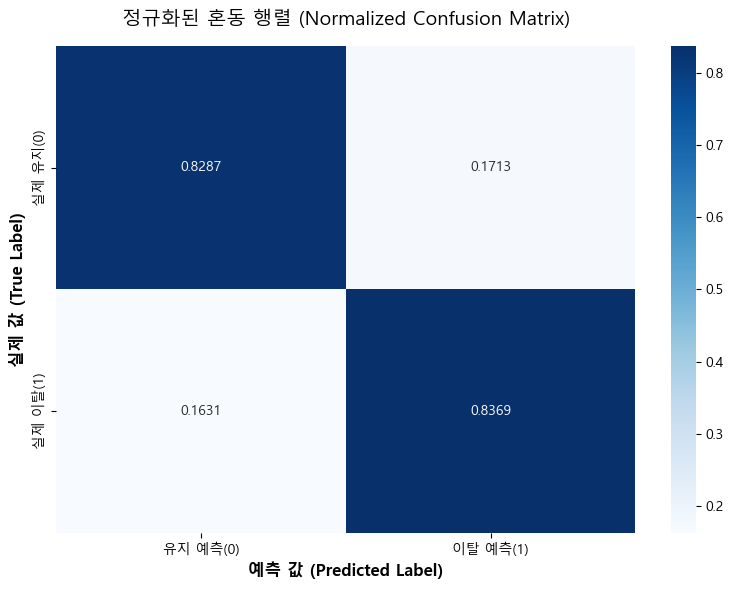


결과: 디스크에 저장된 파이프라인 객체를 활용한 정규화 혼동 행렬 시각화 완료


In [5]:
# %% [독립 실행형] 저장된 프로덕션 객체를 활용한 정규화 혼동 행렬 시각화
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print("[분석] 메모리 상태와 무관한 독립 실행형 정규화 혼동 행렬 산출 시작")

# 1. 원본 데이터 로드 및 정제
file_path = r"C:\dev\SKN27-2nd-1TEAM\00_data\Telco_customer_churn - Telco_Churn.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    raise FileNotFoundError("데이터 파일을 찾을 수 없습니다. 절대 경로를 확인하십시오.")

df['Total Charges'] = pd.to_numeric(df['Total Charges'].replace(' ', np.nan))
df.dropna(subset=['Total Charges'], inplace=True)
df['Churn Value'] = df['Churn Value'].astype(int)

# 2. 파생 변수 생성 (기존 모델이 학습한 40+ 피처 구조 완벽 복원)
internet_services = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
df['Total_Internet_Services'] = (df[internet_services] == 'Yes').sum(axis=1)
df['Total_Streaming'] = (df[['Streaming TV', 'Streaming Movies']] == 'Yes').sum(axis=1)
df['Total_Security'] = (df[['Online Security', 'Online Backup', 'Device Protection', 'Tech Support']] == 'Yes').sum(axis=1)
df['Extra_Charges'] = df['Total Charges'] - (df['Monthly Charges'] * df['Tenure Months'])
df['Price_per_Service'] = df['Monthly Charges'] / (df['Total_Internet_Services'] + 1)
df['Total_to_Monthly_Ratio'] = df['Total Charges'] / (df['Monthly Charges'] + 1e-5)
df['Tenure_to_Monthly_Ratio'] = df['Tenure Months'] / (df['Monthly Charges'] + 1e-5)
df['Monthly_to_Median_Ratio'] = df['Monthly Charges'] / df['Monthly Charges'].median()
df['Avg_Monthly_by_Contract'] = df.groupby('Contract')['Monthly Charges'].transform('mean')
df['Diff_from_Contract_Monthly'] = df['Monthly Charges'] - df['Avg_Monthly_by_Contract']
df['Avg_Tenure_by_Contract'] = df.groupby('Contract')['Tenure Months'].transform('mean')
df['Diff_from_Contract_Tenure'] = df['Tenure Months'] - df['Avg_Tenure_by_Contract']
df['Is_Full_Family'] = ((df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')).astype(int)
df['Is_Single_Senior'] = ((df['Senior Citizen'] == 1) & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)
df['Is_Independent_Youth'] = ((df['Senior Citizen'] == 0) & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)
df['Is_New_Customer'] = (df['Tenure Months'] <= 6).astype(int)
df['Is_Long_Term_Customer'] = (df['Tenure Months'] >= 60).astype(int)
df['Has_Internet_But_No_Service'] = ((df['Internet Service'] != 'No') & (df['Total_Internet_Services'] == 0)).astype(int)
df['Has_All_Services'] = (df['Total_Internet_Services'] == 6).astype(int)
df['Is_Auto_Payment'] = df['Payment Method'].astype(str).str.contains('automatic', case=False).astype(int)
df['Risk_Fiber_MtM'] = ((df['Internet Service'] == 'Fiber optic') & (df['Contract'] == 'Month-to-month')).astype(int)
df['Risk_Payment_Friction'] = ((df['Payment Method'] == 'Electronic check') & (df['Paperless Billing'] == 'Yes')).astype(int)
df['Risk_High_Charge_MtM'] = ((df['Contract'] == 'Month-to-month') & (df['Monthly Charges'] > df['Monthly Charges'].median())).astype(int)
df['Risk_No_TechSupport_Fiber'] = ((df['Internet Service'] == 'Fiber optic') & (df['Tech Support'] == 'No')).astype(int)
df['Tenure_Sq'] = df['Tenure Months'] ** 2
df['Monthly_Charges_Sq'] = df['Monthly Charges'] ** 2
df['Tenure_x_Monthly'] = df['Tenure Months'] * df['Monthly Charges']

# 3. 데이터 분할 (random_state=42 통제로 기존 테스트셋 완벽 동일 추출)
leakage_and_useless_cols = [
    'Churn Reason', 'Churn Label', 'CustomerID', 
    'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Lat Long', 'Churn Score'
]
cols_to_drop = [col for col in leakage_and_useless_cols if col in df.columns]

X = df.drop(columns=cols_to_drop + ['Churn Value'])
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 저장된 프로덕션용 객체 로드
save_dir = r"C:\dev\SKN27-2nd-1TEAM\03_saved_models"
try:
    model = joblib.load(os.path.join(save_dir, 'churn_stacking_model.pkl'))
    encoder = joblib.load(os.path.join(save_dir, 'target_encoder.pkl'))
    scaler = joblib.load(os.path.join(save_dir, 'scaler.pkl'))
    optimal_threshold = joblib.load(os.path.join(save_dir, 'optimal_threshold.pkl'))
    print(f"객체 로드 완료 (적용 예정 최적 임계값: {optimal_threshold:.4f})")
except FileNotFoundError:
    raise FileNotFoundError("저장된 피클(.pkl) 파일을 찾을 수 없습니다. Step 5를 먼저 실행해야 합니다.")

# 5. 테스트 데이터 전처리 및 예측 수행
X_test_encoded = pd.DataFrame(encoder.transform(X_test), columns=encoder.get_feature_names_out(), index=X_test.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test.index)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# 6. 정규화 혼동 행렬 산출 (실제 클래스 비율 기준)
cm_normalized = confusion_matrix(y_test, y_pred_optimal, normalize='true')

# 7. 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.4f', 
    cmap='Blues', 
    cbar=True,
    xticklabels=['유지 예측(0)', '이탈 예측(1)'], 
    yticklabels=['실제 유지(0)', '실제 이탈(1)']
)

plt.title("정규화된 혼동 행렬 (Normalized Confusion Matrix)", fontsize=14, pad=15)
plt.ylabel("실제 값 (True Label)", fontsize=12, fontweight='bold')
plt.xlabel("예측 값 (Predicted Label)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n결과: 디스크에 저장된 파이프라인 객체를 활용한 정규화 혼동 행렬 시각화 완료")